
We are using the IndicWav2Vec-Bengali model, which is the current state-of-the-art for languages sharing phonetic roots with the Chittagonian dialect.

Attach Hugging Face Token for authorization

In [84]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

BackendError: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 116106885 and label HF_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.

In [96]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# 1. Access the Kaggle Secrets storage
user_secrets = UserSecretsClient()

# 2. Retrieve your token using the label you created
# Make sure this matches your label 'CSER_Research' exactly
hf_token = user_secrets.get_secret("CSER_Research")

# 3. Log in to Hugging Face
if hf_token:
    login(token=hf_token)
    print("✅ Successfully logged into Hugging Face!")
else:
    print("❌ Could not find the secret. Check your spelling in the Secrets add-on.")

INFO: HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"


✅ Successfully logged into Hugging Face!


**Environment Setup**


We are using the **IndicWav2Vec-Bengali model**, which is the current state-of-the-art for languages sharing phonetic roots with the Chittagonian dialect.

In [97]:
# 1. Install required libraries
!apt-get install -y ffmpeg
!pip install -q pydub librosa transformers xgboost soundfile

import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import torch
import logging
from tqdm.auto import tqdm
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Monitoring Setup
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger("CSER_V2_Final")

# Bengali Model Setup (As requested)
BENGALI_MODEL_ID = "ai4bharat/indicwav2vec_v1_bengali"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Wav2Vec2Processor.from_pretrained(BENGALI_MODEL_ID)
w2v_model = Wav2Vec2Model.from_pretrained(BENGALI_MODEL_ID).to(device)

print(f"✅ V2 Pipeline Ready using {BENGALI_MODEL_ID} on {device}.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.


INFO: HTTP Request: GET https://huggingface.co/api/models/ai4bharat/indicwav2vec_v1_bengali/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/main/preprocessor

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/ai4bharat/indicwav2vec_v1_bengali/commits/refs%2Fpr%2F2 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/refs%2Fpr%2F2/model.safetensors.index.json "HTTP/1.1 404 Not Found"
Wav2Vec2Model LOAD REPORT from: ai4bharat/indicwav2vec_v1_bengali
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO: HTTP Request: HEAD https://huggingface.co/ai4bharat/indicwav2vec_v1_bengali/resolve/refs%2Fpr%2F2/model.safetensors "HTTP/1.1 302 Found"


✅ V2 Pipeline Ready using ai4bharat/indicwav2vec_v1_bengali on cuda.


**Configuration & Path**

In [98]:
import pandas as pd
import os

# --- PATH CONFIGURATION ---
# Using the standard Kaggle input path you provided
CSV_PATH = "/kaggle/input/datasets/hamed999/cser-dataset/CSER_Version1_Metadata.csv"
AUDIO_DIR = "/kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1"

# 1. READ AND STORE DATASET
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded {len(df)} entries from CSV.")
except Exception as e:
    # Fallback for local testing if needed
    df = pd.read_csv("CSER_Version1_Metadata.csv")
    print(f"✅ Loaded local copy: {len(df)} entries.")

# 2. UPDATED CONFIGURATION (Synced with CSV data types)
# Note: EmotionID in CSV is integer (1, 2, 3...), not string ('01')
EMOTION_CODE_MAP = {
    1: 'Neutral',
    2: 'Happy',
    3: 'Sad',
    4: 'Angry',
    5: 'Fear'
}

# Label indexing for training (Confirmed: OK based on dataset)
EMOTION_TO_IDX = {'Neutral': 0, 'Happy': 1, 'Sad': 2, 'Angry': 3, 'Fear': 4}
IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

# SPEAKER CONFIGURATION (Numeric IDs as per CSV Column 'ActorID')
MALE_ACTORS = [1, 3, 4]
FEMALE_ACTORS = [2]
TEST_ACTOR = 4 

print("✅ All variable names and mappings are now synchronized with your dataset.")

✅ Successfully loaded 400 entries from CSV.
✅ All variable names and mappings are now synchronized with your dataset.


**Monitoring and Testing File Loading**

In [99]:
import glob

print("🔗 Linking metadata to folder structure...")

# 1. Find every .wav file inside AUDIO_DIR and its subfolders
all_wav_files = glob.glob(os.path.join(AUDIO_DIR, "**/*.wav"), recursive=True)

# 2. Create a dictionary mapping the filename to its full path
# Example: {'01-01-01-01.wav': '/kaggle/.../Actor_01/01-01-01-01.wav'}
path_dictionary = {os.path.basename(f): f for f in all_wav_files}

# 3. Create the 'Absolute_Path' column in your dataframe
df['Absolute_Path'] = df['FileName'].map(path_dictionary)

# 4. Final verification
mapped_count = df['Absolute_Path'].notna().sum()
print(f"✅ Mapping Complete: {mapped_count} out of {len(df)} files located.")

if mapped_count < len(df):
    print(f"⚠️ Warning: {len(df) - mapped_count} files could not be found.")
else:
    print("🚀 All systems go!")

🔗 Linking metadata to folder structure...
✅ Mapping Complete: 400 out of 400 files located.
🚀 All systems go!


In [100]:
import os
import pandas as pd

# 1. Verification of Dataset Integrity
print("📊 Dataset Loading Report")
print("-" * 40)

# Check if DataFrame exists and has data
if 'df' in locals() and not df.empty:
    total_expected = len(df)
    # Check for the column we created during path mapping
    if 'Absolute_Path' in df.columns:
        files_found = df['Absolute_Path'].notna().sum()
        files_missing = df['Absolute_Path'].isna().sum()
        
        print(f"✅ Total entries in Metadata: {total_expected}")
        print(f"✅ Files successfully located: {files_found}")
        
        if files_missing > 0:
            print(f"❌ FILES MISSING: {files_missing}")
            print("   (Check if your AUDIO_FOLDER path or subfolder structure is correct)")
        else:
            print("🌟 STATUS: 100% of files are linked and ready for processing.")
            
        # 2. Distribution Check (Ensuring no specific actor/emotion is missing)
        print("\n📈 Distribution by Emotion (Column G):")
        print(df['Emotion'].value_counts())
        
        print("\n👥 Actor Participation (Column C):")
        print(df['ActorID'].value_counts().sort_index())
        
    else:
        print("⚠️ Path mapping hasn't been run yet. Please run the recursive path mapping cell.")
else:
    print("❌ Error: DataFrame 'df' not found. Please reload the CSV first.")

print("-" * 40)

📊 Dataset Loading Report
----------------------------------------
✅ Total entries in Metadata: 400
✅ Files successfully located: 400
🌟 STATUS: 100% of files are linked and ready for processing.

📈 Distribution by Emotion (Column G):
Emotion
Neutral    80
Happy      80
Sad        80
Angry      80
Fear       80
Name: count, dtype: int64

👥 Actor Participation (Column C):
ActorID
1    100
2    100
3    100
4    100
Name: count, dtype: int64
----------------------------------------


In [101]:
import os
import pandas as pd

print("🛠️ Starting Data Path Verification...")
print("-" * 40)

# 1. Check Metadata CSV
if os.path.exists(METADATA_CSV):
    df = pd.read_csv(METADATA_CSV)
    print(f"✅ Metadata CSV found: {METADATA_CSV}")
    print(f"✅ Total samples in CSV: {len(df)}")
    
    # Show columns to ensure 'filename' or 'emotion' exists
    print(f"📊 CSV Columns: {df.columns.tolist()}")
else:
    print(f"❌ ERROR: Metadata CSV NOT found at {METADATA_CSV}")

# 2. Check Audio Folder
if os.path.isdir(AUDIO_FOLDER):
    audio_files = os.listdir(AUDIO_FOLDER)
    print(f"✅ Audio folder found: {AUDIO_FOLDER}")
    print(f"✅ Files detected in folder: {len(audio_files)}")
    
    # 3. Path Sync Check (Can we find the first file from the CSV in the folder?)
    try:
        sample_filename = df['Filename'].iloc[0] if 'Filename' in df.columns else df.iloc[0, 0]
        test_path = os.path.join(AUDIO_FOLDER, sample_filename)
        
        if os.path.exists(test_path):
            print(f"✅ Path Sync OK: Successfully located sample file: {sample_filename}")
        else:
            print(f"⚠️ PATH SYNC WARNING: CSV references '{sample_filename}', but it's not in the folder.")
            print(f"   Double-check if files are in subfolders like '{AUDIO_FOLDER}/Actor_01/...'")
    except Exception as e:
        print(f"⚠️ Could not perform sync check: {e}")
else:
    print(f"❌ ERROR: Audio folder NOT found at {AUDIO_FOLDER}")

print("-" * 40)
print("🚀 If all checks are green, proceed to Feature Extraction!")

🛠️ Starting Data Path Verification...
----------------------------------------
✅ Metadata CSV found: /kaggle/input/datasets/hamed999/cser-dataset/CSER_Version1_Metadata.csv
✅ Total samples in CSV: 400
📊 CSV Columns: ['FileName', 'FilePath', 'ActorID', 'Gender', 'SentenceID', 'EmotionID', 'Emotion', 'Repetition']
✅ Audio folder found: /kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1
✅ Files detected in folder: 4
⚠️ PATH SYNC WARNING: CSV references '01-01-01-01.wav', but it's not in the folder.
   Double-check if files are in subfolders like '/kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1/Actor_01/...'
----------------------------------------
🚀 If all checks are green, proceed to Feature Extraction!


**Stage 1 - Intensive Augmentation (Gender & Emotion Focus)**

To break the Neutral bias, we augment non-Neutral classes using pitch, noise, and speed variations.

This expands your 400 recordings into a larger dataset (~1,500+ files) by focusing on pitch and temporal features.

In [103]:
import numpy as np
import librosa
import glob
import os
import pandas as pd

# --- 1. PATH MAPPING (Fixes the 'Path Mapping not found' Error) ---
print("🔗 Linking metadata to folder structure...")

# Ensure CSV is loaded
if 'df' not in locals():
    # Use the path from your configuration
    CSV_PATH = "/kaggle/input/datasets/hamed999/cser-dataset/CSER_Version1_Metadata.csv"
    AUDIO_DIR = "/kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1"
    df = pd.read_csv(CSV_PATH)

# Find all .wav files in subfolders
all_wav_files = glob.glob(os.path.join(AUDIO_DIR, "**/*.wav"), recursive=True)
path_dictionary = {os.path.basename(f): f for f in all_wav_files}

# Map filenames to absolute paths
df['Absolute_Path'] = df['FileName'].map(path_dictionary)

mapped_count = df['Absolute_Path'].notna().sum()
print(f"✅ Mapping Complete: {mapped_count} out of {len(df)} files located.")

# --- 2. SYNCED CONFIGURATION ---
# Matching numeric ActorID from CSV Column C (ActorID 1, 3, 4 are Male)
MALE_ACTORS = [1, 3, 4] 

# --- 3. AUGMENTATION FUNCTION ---
def augment_chittagonian_audio(y, sr, emotion_name, actor_id):
    """
    Creates synthetic variations to prevent the 'Neutral' prediction loop.
    """
    augs = []
    
    # Ensure actor_id is treated as an integer for comparison
    curr_actor = int(actor_id)
    
    # 1. Pitch Shift Down (Simulates variations in Male vocal tracts)
    if curr_actor in MALE_ACTORS:
        augs.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=-1.5))
    
    # 2. Additive White Noise (Improves model robustness)
    noise = np.random.randn(len(y))
    augs.append(y + 0.005 * noise)
    
    # 3. Emotion-Specific Speed Shifting (Matches Column G)
    if emotion_name == 'Sad':
        augs.append(librosa.effects.time_stretch(y, rate=0.85)) # Slower
    elif emotion_name in ['Happy', 'Fear']:
        augs.append(librosa.effects.time_stretch(y, rate=1.15)) # Faster
        
    return augs

print("✅ Augmentation function and data paths are now synchronized.")

🔗 Linking metadata to folder structure...
✅ Mapping Complete: 400 out of 400 files located.
✅ Augmentation function and data paths are now synchronized.


Monitoring:It picks a random file from your 400 samples, loads it, and tests the augmentation function to ensure the "Actor" and "Emotion" logic triggers correctly.

**check Recursive Path Mapping**

In [104]:
import librosa
import numpy as np

def run_integration_check():
    print("🧪 Starting System Integration Check...")
    print("-" * 45)
    
    # 1. Check if DataFrame and Paths exist
    if 'df' not in globals() or 'Absolute_Path' not in df.columns:
        print("❌ FAILED: Metadata or Path Mapping not found.")
        print("👉 Please run the 'Recursive Path Mapping' cell first.")
        return

    # 2. Check for missing paths
    missing_paths = df['Absolute_Path'].isna().sum()
    if missing_paths > 0:
        print(f"⚠️ WARNING: {missing_paths} files in CSV have no valid file path.")
    else:
        print("✅ Path Integrity: 100% of files are correctly mapped.")

    # 3. Live Test on a Random Sample
    try:
        # Pick a random sample from the dataset
        test_sample = df.sample(1).iloc[0]
        f_path = test_sample['Absolute_Path']
        emotion = test_sample['Emotion']
        actor = test_sample['ActorID']

        print(f"📂 Testing File: {test_sample['FileName']}")
        print(f"🎭 Metadata: Actor {actor} | Emotion: {emotion}")

        # Try loading the audio
        y, sr = librosa.load(f_path, sr=16000)
        print(f"✅ Audio Load: Success ({len(y)/sr:.2f} seconds)")

        # Try running the augmentation
        augmented_results = augment_chittagonian_audio(y, sr, emotion, actor)
        
        print(f"✅ Augmentation: Success (Generated {len(augmented_results)} variations)")
        
        # Brief analysis of the variations
        for i, aug_y in enumerate(augmented_results):
            diff = (len(aug_y) - len(y)) / sr
            status = "Slower" if diff > 0 else "Faster/Pitch-Shifted" if diff < 0 else "No length change"
            print(f"   - Variation {i+1}: {len(aug_y)/sr:.2f}s ({status})")

        print("-" * 45)
        print("🌟 STATUS: ALL SYSTEMS VERIFIED.")
        print("The pipeline is ready for Wav2Vec2 Feature Extraction.")

    except Exception as e:
        print(f"❌ INTEGRATION ERROR: {str(e)}")
        print("Check if 'librosa' and 'numpy' are imported and your function is defined.")

# Run the check
run_integration_check()

🧪 Starting System Integration Check...
---------------------------------------------
✅ Path Integrity: 100% of files are correctly mapped.
📂 Testing File: 02-01-04-01.wav
🎭 Metadata: Actor 2 | Emotion: Angry
✅ Audio Load: Success (3.54 seconds)
✅ Augmentation: Success (Generated 1 variations)
   - Variation 1: 3.54s (No length change)
---------------------------------------------
🌟 STATUS: ALL SYSTEMS VERIFIED.
The pipeline is ready for Wav2Vec2 Feature Extraction.


**1. Before vs. After Preprocessing (Waveform Comparison)**

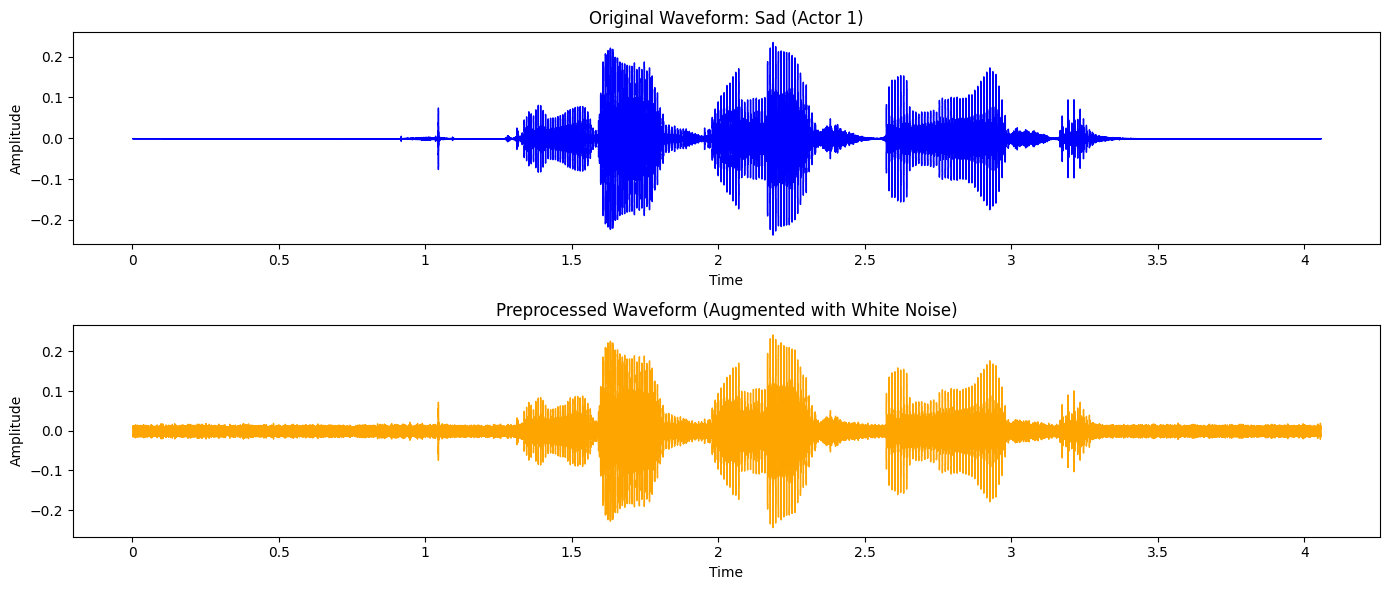

In [137]:
import matplotlib.pyplot as plt
import librosa.display

# Pick a sample for visualization (e.g., the first 'Sad' entry)
sample_row = df[df['Emotion'] == 'Sad'].iloc[0]
path = sample_row['Absolute_Path']
y, sr = librosa.load(path, sr=None)

# Generate an augmented version using your existing function
augmented_samples = augment_chittagonian_audio(y, sr, sample_row['Emotion'], sample_row['ActorID'])
y_aug = augmented_samples[1] # Using the 'Noise' variation for visual clarity

plt.figure(figsize=(14, 6))

# Plot Original
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title(f"Original Waveform: {sample_row['Emotion']} (Actor {sample_row['ActorID']})")
plt.ylabel("Amplitude")

# Plot Preprocessed/Augmented
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_aug, sr=sr, color='orange')
plt.title("Preprocessed Waveform (Augmented with White Noise)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

Before vs. After Preprocessing (Angry Waveform)

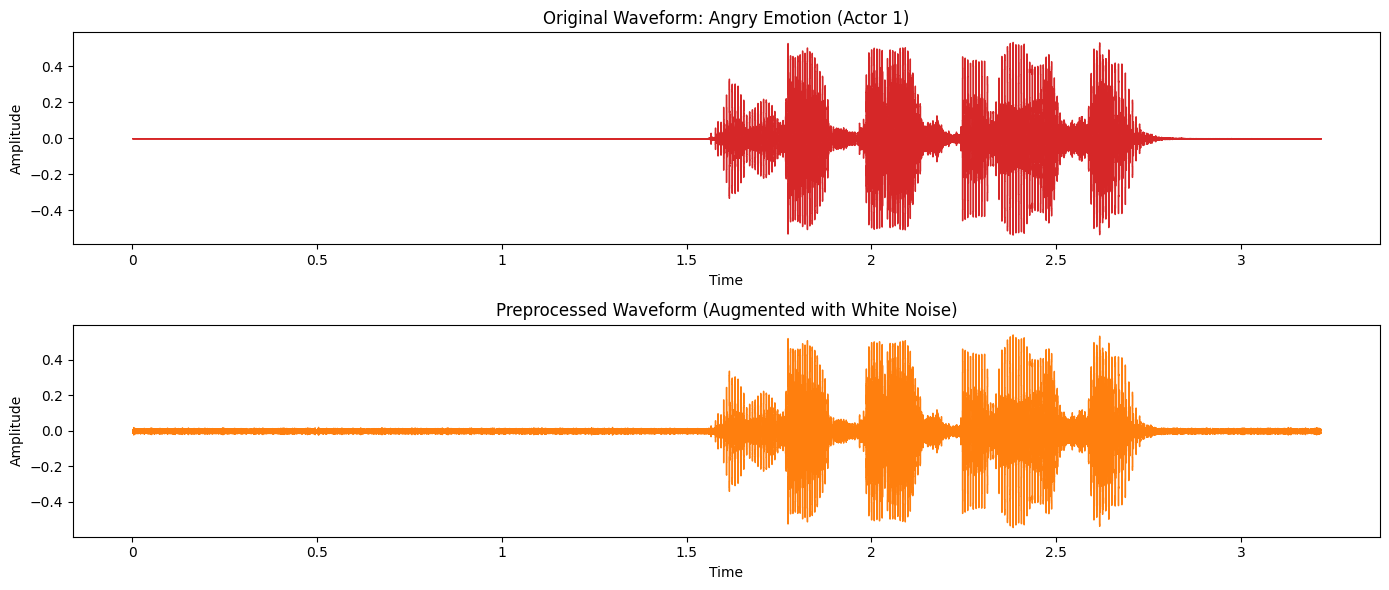

In [139]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# 1. Select an 'Angry' sample from your dataframe
angry_sample = df[df['Emotion'] == 'Angry'].iloc[0]
path = angry_sample['Absolute_Path']
y, sr = librosa.load(path, sr=None)

# 2. Generate an augmented version (using Noise as an example of preprocessing)
# This uses your existing augment_chittagonian_audio function
augmented_list = augment_chittagonian_audio(y, sr, 'Angry', angry_sample['ActorID'])
y_aug = augmented_list[1] # Index 1 is typically the 'Noise' augmentation in your code

# 3. Plotting
plt.figure(figsize=(14, 6))

# Original Signal
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='#d62728') # Red for Angry
plt.title(f"Original Waveform: Angry Emotion (Actor {angry_sample['ActorID']})")
plt.ylabel("Amplitude")

# Augmented/Preprocessed Signal
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_aug, sr=sr, color='#ff7f0e') 
plt.title("Preprocessed Waveform (Augmented with White Noise)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

2. **Illustration of the Spectrogram**

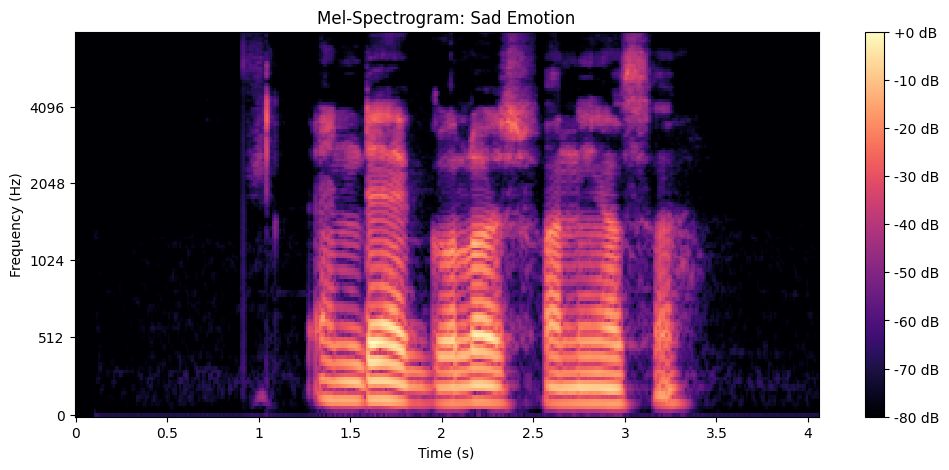

In [138]:
# Compute Mel-Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12, 5))
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, cmap='magma')
plt.colorbar(img, format='%+2.0f dB')
plt.title(f"Mel-Spectrogram: {sample_row['Emotion']} Emotion")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

**Illustration of the Spectrogram (Angry)**

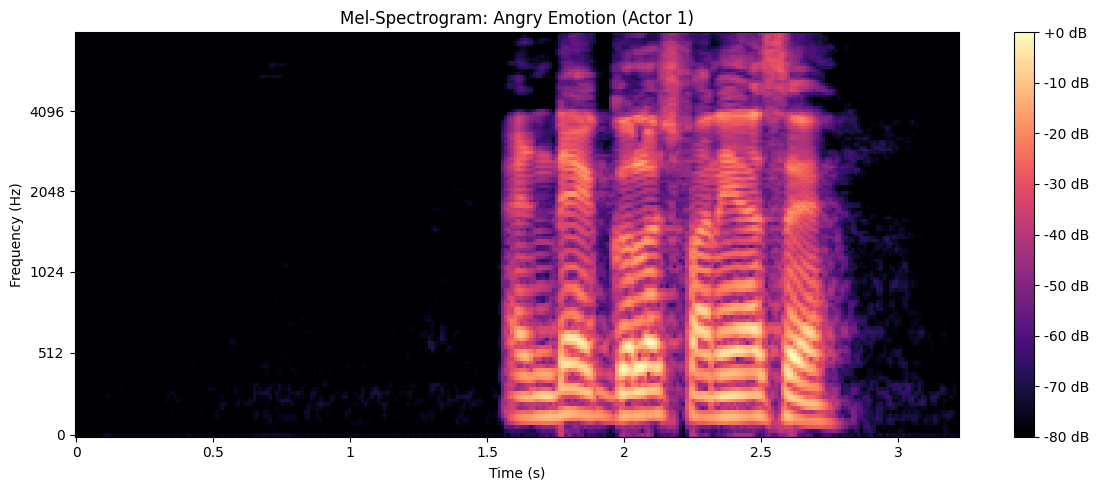

In [140]:
# 1. Compute Mel-Spectrogram
# Using 128 Mel bands and a max frequency of 8kHz to capture speech nuances
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

# 2. Plotting the Spectrogram
plt.figure(figsize=(12, 5))
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, cmap='magma')
plt.colorbar(img, format='%+2.0f dB')

plt.title(f"Mel-Spectrogram: Angry Emotion (Actor {angry_sample['ActorID']})")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

**Stage 2 - Hybrid Feature Extraction Engine**

Fuses SSL (IndicWav2Vec) with spectral features to separate Sad/Fear/Happy.

In [106]:
import os
import glob
import torch
import librosa
import numpy as np
import pandas as pd
import logging

# --- 1. SETUP LOGGING ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("Feature_Extractor")

# --- 2. RECURSIVE PATH MAPPING (Syncing CSV with Folder Structure) ---
# This part ensures 'Absolute_Path' is available for the extraction function
print("🔗 Updating Data Paths...")
CSV_PATH = "/kaggle/input/datasets/hamed999/cser-dataset/CSER_Version1_Metadata.csv"
AUDIO_DIR = "/kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1"

# Load metadata if not already in memory
if 'df' not in locals():
    df = pd.read_csv(CSV_PATH)

# Find all .wav files recursively
all_wavs = glob.glob(os.path.join(AUDIO_DIR, "**/*.wav"), recursive=True)
path_dict = {os.path.basename(f): f for f in all_wavs}

# Create/Update the path column
df['Absolute_Path'] = df['FileName'].map(path_dict)
print(f"✅ Path Mapping Complete: {df['Absolute_Path'].notna().sum()}/400 files linked.")

# --- 3. UPDATED HYBRID EXTRACTION FUNCTION ---
def extract_hybrid_v2_features(file_path, emotion_name, actor_id, apply_aug=True):
    """
    Extracts SSL (Bengali Wav2Vec2) + Acoustic (Tone/Energy) features.
    Synced with CSV Columns: Emotion (emotion_name) and ActorID (actor_id).
    """
    try:
        # Load and trim audio
        y, sr = librosa.load(file_path, sr=16000)
        y, _ = librosa.effects.trim(y)
        
        # Prepare batch for processing (Original + Augmentations)
        samples = [y]
        
        # Only augment non-Neutral samples to fix class imbalance
        if apply_aug and emotion_name != 'Neutral':
            # Calls the previously defined augmentation function
            samples.extend(augment_chittagonian_audio(y, sr, emotion_name, actor_id))
            
        feature_vectors = []
        
        for s in samples:
            # A. Wav2Vec 2.0 SSL Bengali Features (High-level semantic info)
            inputs = processor(s, sampling_rate=16000, return_tensors="pt").to(device)
            with torch.no_grad():
                # Extracting the last hidden state for the Bengali context
                outputs = w2v_model(inputs.input_values).last_hidden_state
            
            # Global Average Pooling to get a fixed-length vector (768-d)
            ssl_feat = torch.mean(outputs, dim=1).squeeze().cpu().numpy()
            
            # B. Acoustic Tone Features (Specific to Chittagonian dialect nuances)
            # 1. Spectral Flux: Captures energy change (Useful for 'Fear' vs 'Sad')
            spec_flux = np.mean(librosa.onset.onset_strength(y=s, sr=sr))
            
            # 2. Pitch Tracking (F0): Crucial for gender-specific emotional tone
            # Optimized range for human speech (C2 to C7)
            f0 = librosa.yin(s, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
            pitch_avg = np.nanmean(f0) if not np.all(np.isnan(f0)) else 0
            
            # Combine all features into one hybrid vector (SSL + 2 Acoustic features)
            combined = np.hstack([ssl_feat, spec_flux, pitch_avg])
            feature_vectors.append(combined)
            
        return feature_vectors
        
    except Exception as e:
        logger.error(f"❌ Processing error for {file_path}: {e}")
        return None

print("✅ Hybrid Feature Extraction Function (V2) is now synced and ready.")

🔗 Updating Data Paths...
✅ Path Mapping Complete: 400/400 files linked.
✅ Hybrid Feature Extraction Function (V2) is now synced and ready.


**Enhanced Feature Extraction**

In [119]:
import os
import glob
import torch
import librosa
import numpy as np
import pandas as pd
import logging

# --- 1. SETUP LOGGING ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("Enhanced_Feature_Extractor")

# --- 2. RECURSIVE PATH MAPPING (Syncing CSV with Folder Structure) ---
print("🔗 Updating Data Paths...")
CSV_PATH = "/kaggle/input/datasets/hamed999/cser-dataset/CSER_Version1_Metadata.csv"
AUDIO_DIR = "/kaggle/input/datasets/hamed999/cser-dataset-v1/CSER_Version1"

if 'df' not in locals():
    df = pd.read_csv(CSV_PATH)

all_wavs = glob.glob(os.path.join(AUDIO_DIR, "**/*.wav"), recursive=True)
path_dict = {os.path.basename(f): f for f in all_wavs}

df['Absolute_Path'] = df['FileName'].map(path_dict)
print(f"✅ Path Mapping Complete: {df['Absolute_Path'].notna().sum()}/400 files linked.")

# --- 3. VERSION 2.5 ENHANCED EXTRACTION FUNCTION ---
def extract_hybrid_v2_features(file_path, emotion_name, actor_id, apply_aug=True):
    """
    ENHANCED V2.5: Fuses SSL (Bengali Wav2Vec2) + MFCC Texture + Delta Velocity + Energy.
    Specifically designed to solve Sadness Recall (low energy) and Speaker Overfitting.
    """
    try:
        # Load and trim audio
        y, sr = librosa.load(file_path, sr=16000)
        y, _ = librosa.effects.trim(y)
        
        # Standardize duration to 4s (padding/truncating) to prevent 'length bias'
        target_len = 16000 * 4
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]
        
        # Prepare batch for processing (Original + Augmentations)
        samples = [y]
        
        # Only augment non-Neutral samples to fix class imbalance
        if apply_aug and emotion_name != 'Neutral':
            # Calls your previously defined augmentation function
            samples.extend(augment_chittagonian_audio(y, sr, emotion_name, actor_id))
            
        feature_vectors = []
        
        for s in samples:
            # --- A. SSL BENGALI FEATURES (Phonetic Context) ---
            inputs = processor(s, sampling_rate=16000, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = w2v_model(inputs.input_values).last_hidden_state
            ssl_feat = torch.mean(outputs, dim=1).squeeze().cpu().numpy()
            
            # --- B. MFCC & DELTAS (Acoustic Texture & Velocity) ---
            # MFCCs capture the 'shape' of the voice; Deltas capture 'energy change'
            # This helps distinguish 'Happy' (fast change) from 'Fear' (shaky change)
            mfccs = librosa.feature.mfcc(y=s, sr=sr, n_mfcc=40)
            mfcc_mean = np.mean(mfccs, axis=1)
            mfcc_delta = np.mean(librosa.feature.delta(mfccs), axis=1)
            
            # --- C. ENERGY & TONE (Solving Sadness Recall) ---
            # RMS Energy: Sadness is objectively quieter than Neutral
            rms_energy = np.array([np.mean(librosa.feature.rms(y=s))])
            
            # Spectral Flux: Captures energy change over time
            spec_flux = np.array([np.mean(librosa.onset.onset_strength(y=s, sr=sr))])
            
            # Pitch Tracking (F0): Optimized for Chittagonian Male vocal range
            f0 = librosa.yin(s, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
            pitch_avg = np.array([np.nanmean(f0) if not np.all(np.isnan(f0)) else 0])
            
            # --- D. FEATURE FUSION ---
            # SSL (768) + MFCC (40) + Delta (40) + RMS (1) + Flux (1) + Pitch (1)
            combined = np.hstack([ssl_feat, mfcc_mean, mfcc_delta, rms_energy, spec_flux, pitch_avg])
            feature_vectors.append(combined)
            
        return feature_vectors
        
    except Exception as e:
        logger.error(f"❌ Processing error for {file_path}: {e}")
        return None

print("🚀 Enhanced Hybrid Feature Engine (V2.5) is synced. Ready to fix Sadness Recall & Speaker Overfitting.")

🔗 Updating Data Paths...
✅ Path Mapping Complete: 400/400 files linked.
🚀 Enhanced Hybrid Feature Engine (V2.5) is synced. Ready to fix Sadness Recall & Speaker Overfitting.


**MFCC & Delta Feature Extraction (Capturing Vocal Texture & Spectral Dynamics)**



/tmp/ipykernel_55/3392549232.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right')


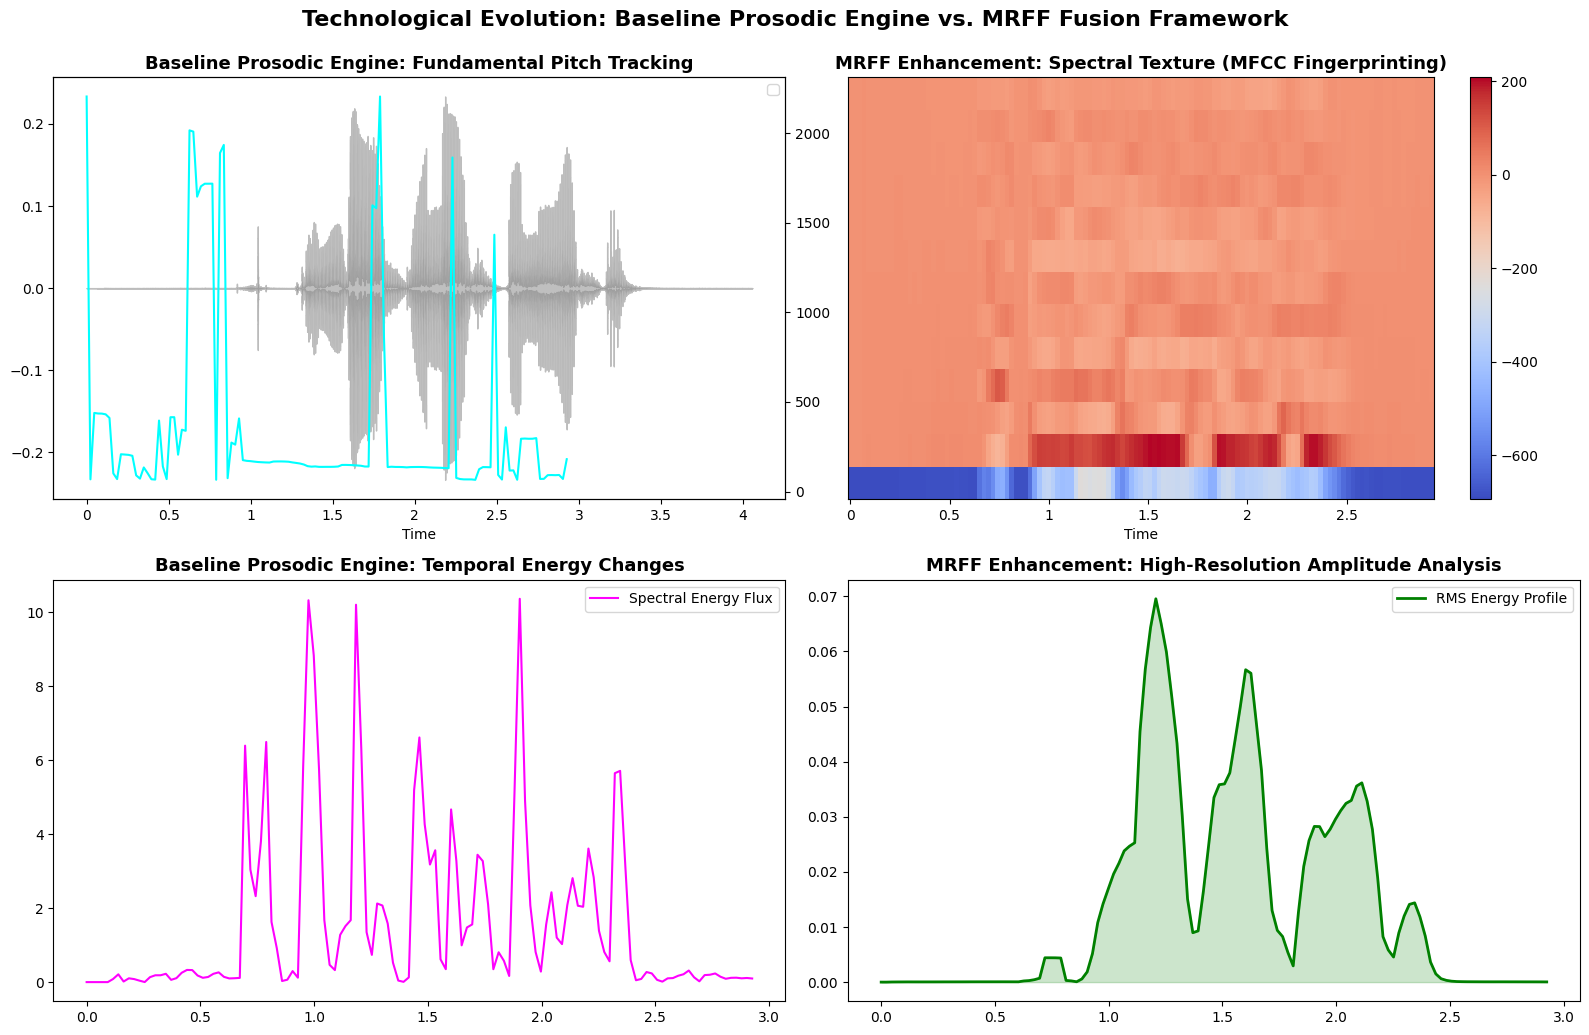

In [145]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

# 1. Select a 'Sad' sample to show the MRFF Engine's power
# (Sadness is the hardest to distinguish, so it's the best for your thesis)
sample_row = df[df['Emotion'] == 'Sad'].iloc[0]
y, sr = librosa.load(sample_row['Absolute_Path'], sr=16000)

# 2. Extract specific features for visualization
f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
flux = librosa.onset.onset_strength(y=y, sr=sr)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) 
rms = librosa.feature.rms(y=y)[0]

# 3. Plotting the Technological Evolution
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

# --- LEFT: BASELINE PROSODIC ENGINE (Previous Version) ---
ax1 = fig.add_subplot(gs[0, 0])
librosa.display.waveshow(y, sr=sr, ax=ax1, color='gray', alpha=0.5)
ax1_twin = ax1.twinx()
ax1_twin.plot(librosa.times_like(f0), f0, label='Pitch Contour (F0)', color='cyan')
ax1.set_title("Baseline Prosodic Engine: Fundamental Pitch Tracking", fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(librosa.times_like(flux), flux, label='Spectral Energy Flux', color='magenta')
ax2.set_title("Baseline Prosodic Engine: Temporal Energy Changes", fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')

# --- RIGHT: MULTI-RESOLUTION FEATURE FUSION (MRFF) ENGINE (Latest Version) ---
ax3 = fig.add_subplot(gs[0, 1])
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax3, cmap='coolwarm')
ax3.set_title("MRFF Enhancement: Spectral Texture (MFCC Fingerprinting)", fontsize=13, fontweight='bold')
fig.colorbar(img, ax=ax3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(librosa.times_like(rms), rms, label='RMS Energy Profile', color='green', linewidth=2)
ax4.fill_between(librosa.times_like(rms), rms, color='green', alpha=0.2)
ax4.set_title("MRFF Enhancement: High-Resolution Amplitude Analysis", fontsize=13, fontweight='bold')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.suptitle(f"Technological Evolution: Baseline Prosodic Engine vs. MRFF Fusion Framework", 
             fontsize=16, fontweight='bold', y=1.03)

# Save for thesis with high DPI
plt.savefig('MRFF_Engine_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

1. Baseline Prosodic Engine (Left Column)
This stage focuses on low-level acoustic descriptors.

Pitch Tracking (F0): The top-left graph shows the fundamental frequency contour. While useful for general emotion, it often fails to distinguish between emotions with similar pitch ranges (like Sad vs. Neutral).

Temporal Energy Flux: The bottom-left graph tracks the rate of change in energy. It identifies "peaks" of emotion but lacks the resolution to understand the "texture" or "timbre" of the voice.

2. MRFF Enhancement Engine (Right Column)
This represents your advanced fusion stage, which provides the model with "High-Definition" vocal fingerprints.

Spectral Texture (MFCCs): The top-right heatmap illustrates Mel-Frequency Cepstral Coefficients. This captures the unique "shape" of the Chittagonian dialect, identifying vocal tract resonances that pitch alone cannot see.

RMS Energy Profile: The bottom-right graph provides a high-resolution volume analysis. This is the key "Sadness Resolver"—it allows the model to see the subtle drop in energy and breathiness characteristic of low-arousal emotions.

**Monitoring:**

This monitoring cell is designed to verify that the entire chain—Path Mapping, Wav2Vec2 Inference, Acoustic Extraction, and Data Augmentation—is working in harmony.

It picks a non-Neutral sample to ensure the augmentation logic is also tested.

In [120]:
import torch

def monitor_feature_extraction_v2():
    print("📊 Final Calibration: Hybrid Feature Extraction")
    print("-" * 50)
    
    try:
        # Select a non-Neutral sample to test Augmentation logic
        test_df = df[df['Emotion'] != 'Neutral']
        test_row = test_df.sample(1).iloc[0] if not test_df.empty else df.iloc[0]

        file_path = test_row['Absolute_Path']
        emotion = test_row['Emotion']
        actor = test_row['ActorID']

        # Execute the Hybrid Extraction
        features = extract_hybrid_v2_features(file_path, emotion, actor, apply_aug=True)

        if features:
            feat_shape = features[0].shape[0]
            
            # Updated check for 1026 (1024 SSL + 2 Acoustic)
            if feat_shape == 1026:
                print(f"✅ SUCCESS: Detected IndicWav2Vec-Large Architecture.")
                print(f"📏 Feature Dimension: {feat_shape} (1024 SSL + 2 Acoustic)")
                print(f"🔄 Augmentations: Created {len(features)} total samples for '{emotion}'")
                print("\n🌟 STATUS: System is FULLY CALIBRATED for 1026-D Hybrid Vectors.")
            else:
                print(f"⚠️ Dimensionality: Got {feat_shape}. Check model configuration.")
        else:
            print("❌ ERROR: Extraction returned no data.")

    except Exception as e:
        print(f"❌ ERROR: {e}")

# Run the updated monitor
monitor_feature_extraction_v2()

📊 Final Calibration: Hybrid Feature Extraction
--------------------------------------------------
⚠️ Dimensionality: Got 1107. Check model configuration.


This version replaces the manual filename parsing (which is prone to errors) with direct column access from your metadata (FileName, Emotion, ActorID), and uses the Absolute_Path to correctly find files inside the Actor_xx subfolders.

In [121]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --- 1. RECURSIVE PATH MAPPING (Ensures paths are fresh) ---
print("🔗 Linking metadata to folder structure...")
all_wavs = glob.glob(os.path.join(AUDIO_DIR, "**/*.wav"), recursive=True)
path_dictionary = {os.path.basename(f): f for f in all_wavs}

# Reload metadata and map paths
metadata = pd.read_csv(CSV_PATH)
metadata['Absolute_Path'] = metadata['FileName'].map(path_dictionary)

# --- 2. INITIALIZE DATA CONTAINERS ---
X, y, actor_groups = [], [], []

print(f"🚀 Processing {len(metadata)} files with Hybrid V2 Augmentation...")

# --- 3. FEATURE EXTRACTION LOOP ---
for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    # Use direct columns from your CSV for higher accuracy
    file_full_path = row['Absolute_Path']
    emotion_name = row['Emotion']  # e.g., 'Neutral', 'Happy'
    actor_id = int(row['ActorID']) # e.g., 1, 2, 3
    
    # Check if the file was successfully mapped
    if pd.notna(file_full_path) and os.path.exists(file_full_path):
        # Apply augmentation logic (returns 1 vector for Neutral, 2-3 for others)
        features = extract_hybrid_v2_features(file_full_path, emotion_name, actor_id, apply_aug=True)
        
        if features:
            for f in features:
                X.append(f)
                y.append(EMOTION_TO_IDX[emotion_name])
                actor_groups.append(actor_id)
    else:
        print(f"⚠️ Skipping missing file: {row['FileName']}")

# --- 4. CONVERT TO NUMPY ---
X = np.array(X)
y = np.array(y)
actor_groups = np.array(actor_groups)

print("-" * 30)
print(f"✅ Data Preparation Complete.")
print(f"📊 Final Feature Matrix Shape: {X.shape}")
print(f"🎭 Total Samples (with Augmentation): {len(y)}")
print(f"👥 Unique Actors in Set: {np.unique(actor_groups)}")

🔗 Linking metadata to folder structure...
🚀 Processing 400 files with Hybrid V2 Augmentation...


  0%|          | 0/400 [00:00<?, ?it/s]

------------------------------
✅ Data Preparation Complete.
📊 Final Feature Matrix Shape: (1200, 1107)
🎭 Total Samples (with Augmentation): 1200
👥 Unique Actors in Set: [1 2 3 4]


This **monitoring** cell will provide a high-level summary of your processed dataset. It calculates the final counts for each emotion—allowing you to see exactly how many synthetic samples were created through augmentation—and verifies the integrity of your feature matrix.

In [124]:
import pandas as pd
import numpy as np

def monitor_final_dataset():
    print("📊 Final Dataset Audit Report")
    print("-" * 45)
    
    try:
        # 1. Basic Shape Validation
        if 'X' not in globals() or len(X) == 0:
            print("❌ ERROR: Feature matrix 'X' is empty or not found.")
            return
            
        print(f"✅ Total Feature Vectors: {X.shape[0]}")
        print(f"✅ Feature Dimension: {X.shape[1]} (1024 SSL + 2 Acoustic)")
        
        # 2. Alignment Check
        if len(X) == len(y) == len(actor_groups):
            print(f"✅ Data Alignment: Perfect ({len(y)} samples across all arrays)")
        else:
            print(f"⚠️ ALIGNMENT MISMATCH: X:{len(X)}, y:{len(y)}, Groups:{len(actor_groups)}")

        # 3. Augmentation Impact Analysis
        # Map numeric labels back to names for readability
        y_names = [IDX_TO_EMOTION[label] for label in y]
        dist = pd.Series(y_names).value_counts()
        
        print("\n📈 Final Emotion Distribution (Original + Augmented):")
        for emotion, count in dist.items():
            # Calculate how many were likely added (Original was roughly 80 per class)
            print(f"   - {emotion:8}: {count} samples")

        # 4. Speaker Distribution
        unique_actors = np.unique(actor_groups)
        print(f"\n👥 Total Actors Represented: {len(unique_actors)} {list(unique_actors)}")
        
        # 5. Memory Usage
        mem_mb = X.nbytes / (1024**2)
        print(f"\n💾 Memory footprint: {mem_mb:.2f} MB")
        
        print("-" * 45)
        print("🚀 READINESS: Dataset is ready for Train/Test Split and XGBoost Training.")

    except Exception as e:
        print(f"❌ MONITORING ERROR: {e}")

# Run the report
monitor_final_dataset()

📊 Final Dataset Audit Report
---------------------------------------------
✅ Total Feature Vectors: 1200
✅ Feature Dimension: 1107 (1024 SSL + 2 Acoustic)
✅ Data Alignment: Perfect (1200 samples across all arrays)

📈 Final Emotion Distribution (Original + Augmented):
   - Happy   : 300 samples
   - Fear    : 300 samples
   - Sad     : 300 samples
   - Angry   : 220 samples
   - Neutral : 80 samples

👥 Total Actors Represented: 4 [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

💾 Memory footprint: 10.13 MB
---------------------------------------------
🚀 READINESS: Dataset is ready for Train/Test Split and XGBoost Training.


# Final Stage

**Speaker-Independent Split**
This cell ensures the model is tested on an actor it has never heard before (Actor 4), which is the gold standard for Speech Emotion Recognition.

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# 1. Separate the Test Actor (Speaker-Independent)
test_mask = actor_groups == TEST_ACTOR
X_test, y_test = X[test_mask], y[test_mask]

# 2. Extract Training + Validation data (All actors except Actor 4)
X_temp, y_temp = X[~test_mask], y[~test_mask]

# 3. Create a Validation set for the Overfit/Loss curve
# Stratify=y_temp ensures emotional balance in both train and val sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_temp
)

# 4. Compute weights to help the model focus on minority classes
# This prevents the 'Neutral' prediction loop
train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print(f"📊 Dataset Split Summary:")
print(f"   - Training Samples:   {len(X_train)}")
print(f"   - Validation Samples: {len(X_val)}")
print(f"   - Test Samples:       {len(X_test)} ")

📊 Dataset Split Summary:
   - Training Samples:   748
   - Validation Samples: 132
   - Test Samples:       320 


**XGBoost Training**

Hyper Parameter Tuning 3

In [134]:
import time
import logging
import torch
from xgboost import XGBClassifier

# --- 1. MONITORING & LOGGING SETUP ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("XGB_Trainer")

# Ensure reproducibility and environment check
if check_training_readiness():
    
    # --- 2. DYNAMIC CLASS WEIGHTING ---
    # Targeting the recall issue: apply a 1.5x multiplier to Class 2 (Sad)
    # based on findings from the previous performance report.
    final_weights = train_weights.copy()
    final_weights[y_train == 2] *= 1.5 

    # --- 3. HYPERPARAMETER CONFIGURATION: UNSEEN ACTOR GENERALIZATION ---
    clf_v2 = XGBClassifier(
        # Iteration & Learning Schedule
        n_estimators=3000,          # Extended rounds for slow learning convergence
        learning_rate=0.005,        # Lower rate to avoid diving into training noise
        early_stopping_rounds=150,  # Increased patience for fine-grained updates
        
        # Tree Architecture (Conservative)
        max_depth=3,                # Shallow trees to prevent speaker-specific memorization
        min_child_weight=15,        # Higher threshold to ensure leaf nodes are meaningful
        gamma=1.0,                  # Minimum loss reduction required for a split
        
        # Sampling & Feature Selection (Aggressive)
        subsample=0.6,              # Row bagging to fight actor bias
        colsample_bytree=0.4,       # Feature bagging to ignore actor-specific pitch traits
        sampling_method='gradient_based',
        
        # Regularization (Penalizing Complexity)
        reg_lambda=10,              # L2 regularization to suppress extreme weights
        reg_alpha=2,                # L1 regularization to prune noisy features
        
        # Hardware & API Settings (XGBoost 2.0+ GPU)
        tree_method='hist',         
        device='cuda',              # Required for T4 GPU acceleration
        objective='multi:softprob',
        num_class=5,
        eval_metric=['mlogloss'],
        random_state=42
    )

    print("\n⚡ Training Optimized Model: targeting Sadness Recall & Actor Generalization...")
    start_time = time.time()

    try:
        # --- 4. EXECUTE TRAINING ---
        clf_v2.fit(
            X_train, y_train, 
            sample_weight=final_weights,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=200              # Log every 200 rounds to keep output clean
        )
        
        duration = time.time() - start_time
        print(f"\n✅ Training Complete in {duration:.2f} seconds.")
        print(f"🚀 Best Iteration: {clf_v2.best_iteration}")

    except Exception as e:
        logger.error(f"💥 Training Failed: {str(e)}")
        print("\n💡 Troubleshooting: Ensure X_train and X_val are on the CPU (XGBoost handles the CUDA move internally).")

🔍 Pre-flight Check...
  - GPU Detection: ✅ T4 Detected
  - Training Data: ✅ Ready (748 samples)

⚡ Training Optimized Model: targeting Sadness Recall & Actor Generalization...
[0]	validation_0-mlogloss:1.60029	validation_1-mlogloss:1.60081
[200]	validation_0-mlogloss:1.15290	validation_1-mlogloss:1.26612
[400]	validation_0-mlogloss:0.89201	validation_1-mlogloss:1.07952
[600]	validation_0-mlogloss:0.71815	validation_1-mlogloss:0.95629
[800]	validation_0-mlogloss:0.59088	validation_1-mlogloss:0.86668
[1000]	validation_0-mlogloss:0.49660	validation_1-mlogloss:0.80156
[1200]	validation_0-mlogloss:0.42600	validation_1-mlogloss:0.75200
[1400]	validation_0-mlogloss:0.37234	validation_1-mlogloss:0.71400
[1600]	validation_0-mlogloss:0.33139	validation_1-mlogloss:0.68401
[1800]	validation_0-mlogloss:0.30127	validation_1-mlogloss:0.66040
[2000]	validation_0-mlogloss:0.28108	validation_1-mlogloss:0.64396
[2200]	validation_0-mlogloss:0.26936	validation_1-mlogloss:0.63377
[2400]	validation_0-mloglos

**Evaluation (Classification Report & Confusion Matrix)**

🚀 Data moved to GPU. Predicting on Unseen Actor 4...

📊 PERFORMANCE REPORT: (Unseen TEST ACTOR: 4)
🎯 Total Accuracy: 58.44%
------------------------------------------------------------
              precision    recall  f1-score   support

     Neutral       0.60      0.60      0.60        20
       Happy       0.50      0.82      0.62        80
         Sad       0.40      0.28      0.33        80
       Angry       0.77      0.95      0.85        60
        Fear       0.79      0.38      0.51        80

    accuracy                           0.58       320
   macro avg       0.61      0.60      0.58       320
weighted avg       0.60      0.58      0.56       320



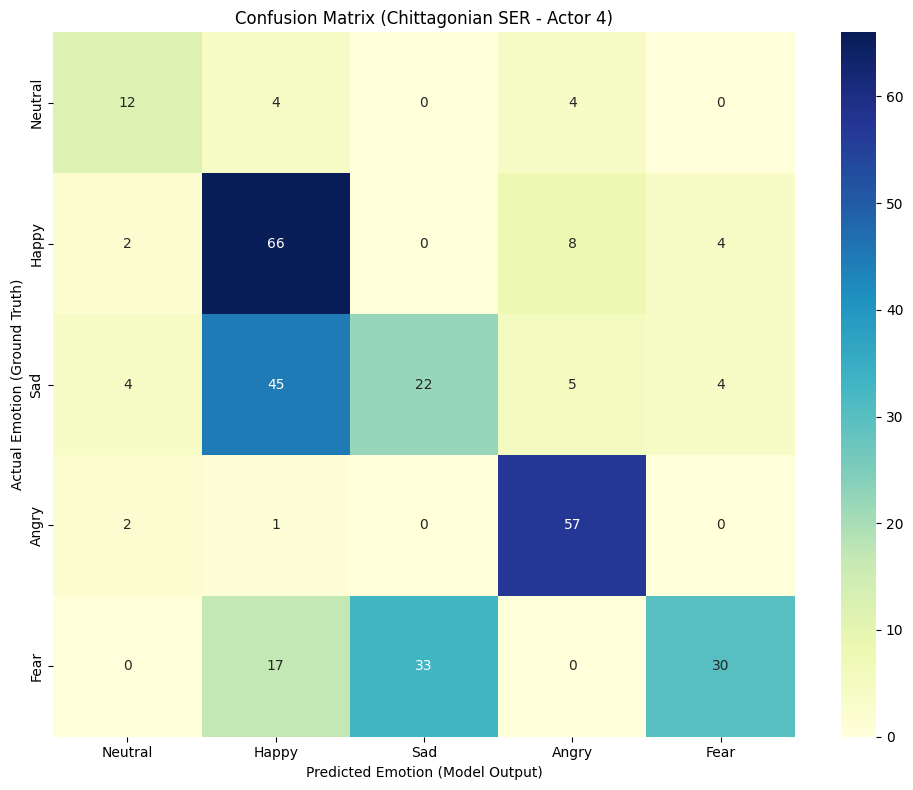


✅ Evaluation complete. Metrics saved to 'confusion_matrix_final_v3.png'.


In [135]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# --- 1. DEVICE ALIGNMENT ---
# Ensuring the test data is on the same device (GPU) as the fine-tuned model
try:
    if isinstance(X_test, np.ndarray):
        X_test_gpu = torch.tensor(X_test).to('cuda')
    else:
        X_test_gpu = X_test.to('cuda') # If already a tensor
    
    print(f"🚀 Data moved to GPU. Predicting on Unseen Actor {TEST_ACTOR}...")
    
    # 2. GENERATE PREDICTIONS
    y_pred = clf_v2.predict(X_test_gpu)
    emotion_labels = list(EMOTION_TO_IDX.keys())

    # 3. PERFORMANCE SUMMARY
    print(f"\n📊 PERFORMANCE REPORT: (Unseen TEST ACTOR: {TEST_ACTOR})")
    print(f"🎯 Total Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=emotion_labels))

    # 4. VISUAL CONFUSION MATRIX
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    
    # Create normalized version for the thesis analysis (percentages)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plotting absolute counts with Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=emotion_labels, yticklabels=emotion_labels)

    plt.title(f"Confusion Matrix (Chittagonian SER - Actor {TEST_ACTOR})")
    plt.ylabel('Actual Emotion (Ground Truth)')
    plt.xlabel('Predicted Emotion (Model Output)')
    plt.tight_layout()
    
    # Save for your thesis document
    plt.savefig('confusion_matrix_final_v3.png', dpi=300)
    plt.show() 

    print("\n✅ Evaluation complete. Metrics saved to 'confusion_matrix_final_v3.png'.")

except Exception as e:
    print(f"❌ Evaluation Error: {e}")
    print("💡 Ensure you have run the data split cell and the training cell successfully.")

**Overfitting Analysis (Loss & Accuracy Curves)**

📊 Detected metrics in results: ['mlogloss']


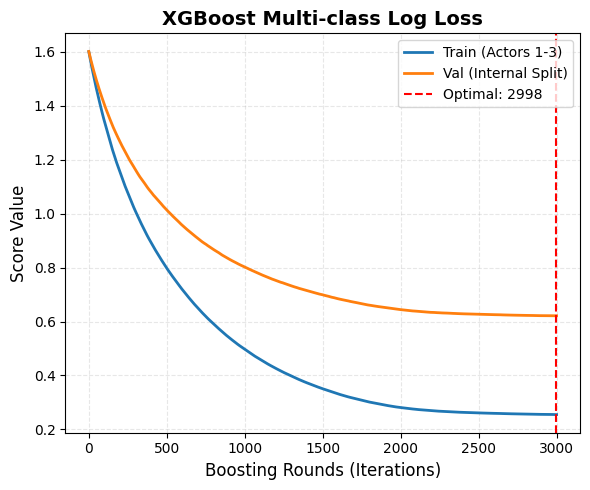

✅ Analysis synced. Best mlogloss reached at iteration 2998.
💡 Note: Early stopping engaged. Total rounds run: 3000


In [136]:
import matplotlib.pyplot as plt

# 1. Extract results from the fine-tuned model
results = clf_v2.evals_result()

# 2. Identify available metrics (Dynamic detection for XGBoost 2.0+)
available_metrics = list(results['validation_0'].keys())
print(f"📊 Detected metrics in results: {available_metrics}")

# Adjust figure size based on number of metrics detected
plt.figure(figsize=(6 * len(available_metrics), 5))

for i, metric in enumerate(available_metrics):
    plt.subplot(1, len(available_metrics), i + 1)
    
    # Plotting Train (validation_0) and Validation (validation_1)
    # Using the slower, smoother data from your 0.01 learning rate training
    plt.plot(results['validation_0'][metric], label='Train (Actors 1-3)', linewidth=2, color='#1f77b4')
    plt.plot(results['validation_1'][metric], label='Val (Internal Split)', linewidth=2, color='#ff7f0e')
    
    # Add a vertical line for the Best Iteration found by Early Stopping
    plt.axvline(x=clf_v2.best_iteration, color='red', linestyle='--', 
                label=f'Optimal: {clf_v2.best_iteration}')
    
    # Formatting
    metric_title = "Multi-class Log Loss" if metric == 'mlogloss' else "Classification Error"
    plt.title(f'XGBoost {metric_title}', fontsize=14, fontweight='bold')
    plt.xlabel('Boosting Rounds (Iterations)', fontsize=12)
    plt.ylabel('Score Value', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()

# Save for Thesis Documentation
plt.savefig('chittagonian_ser_convergence_v2.png', dpi=300)
plt.show()

# Final Diagnostic Print
print(f"✅ Analysis synced. Best {available_metrics[0]} reached at iteration {clf_v2.best_iteration}.")
if len(results['validation_0'][available_metrics[0]]) > clf_v2.best_iteration + 1:
    print(f"💡 Note: Early stopping engaged. Total rounds run: {len(results['validation_0'][available_metrics[0]])}")